<a href="https://colab.research.google.com/github/CaptSalamanca/TESS-data/blob/main/TESS_Data_Research_on_TOI_1853b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

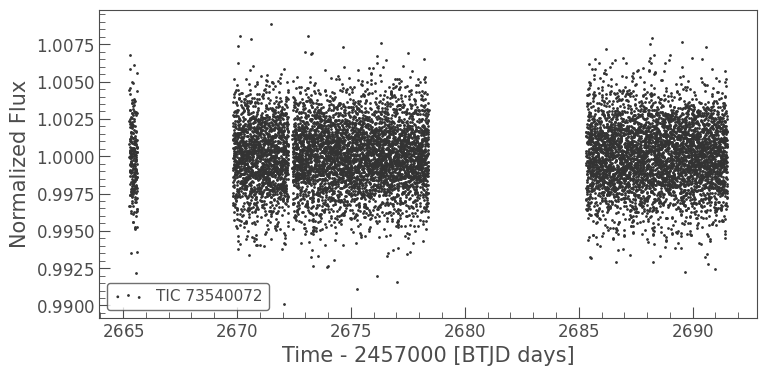

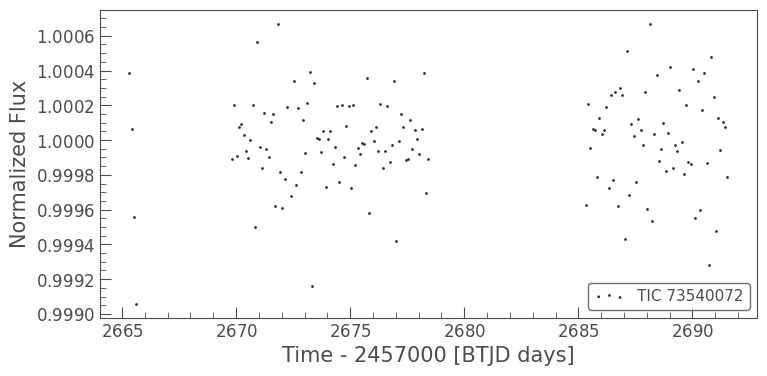

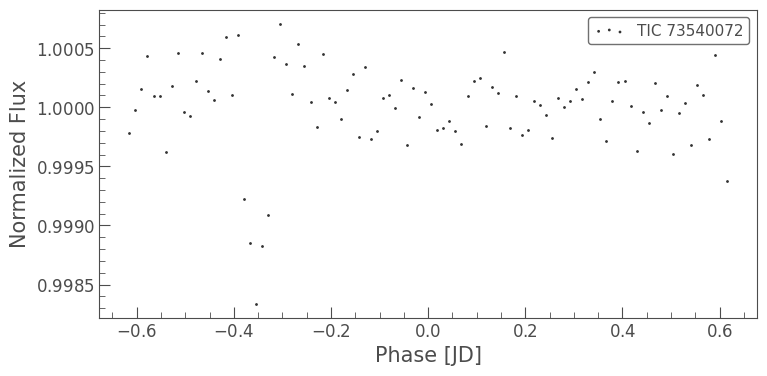

In [108]:
# 1. Download the TESS data for TOI-1853
search_result = lk.search_lightcurve('TOI-1853', author='SPOC')
# We'll just grab the first sector to keep it simple
lc_raw = search_result[0].download()

# 2. Clean it up (Remove the star's slow drift)
lc_clean = lc_raw.remove_nans().flatten(window_length=401)

# 3. Plot it wide so we can see the "forest" before the "trees"
lc_clean.scatter()
lc_clean.bin(time_bin_size=0.1).scatter()
mystery_fold = lc_clean.fold(period=1.243, epoch_time=2671.2)
mystery_fold.bin(bins=100).scatter()

In [109]:
import batman
import numpy as np

# Create the parameters based on your "hunt"
params = batman.TransitParams()
params.t0 = -0.02
params.per = 1.2436258                  # The orbital period you found
params.rp = 0.050                    # YOUR MEASUREMENT (sqrt of 0.0017)
params.a = 4.4                       # Distance from star (in stellar radii)
params.inc = 84.7                    # The tilt of the orbit
params.ecc = 0.03                      # Circular orbit
params.w = 90.                       # Longitude of periastron
params.u = [0.3, 0.2]                # Standard star-fading (limb darkening)
params.limb_dark = "quadratic"

# Create the "Theory" line
t = binned_lc.time.value
m = batman.TransitModel(params, t)
model_flux = m.light_curve(params)

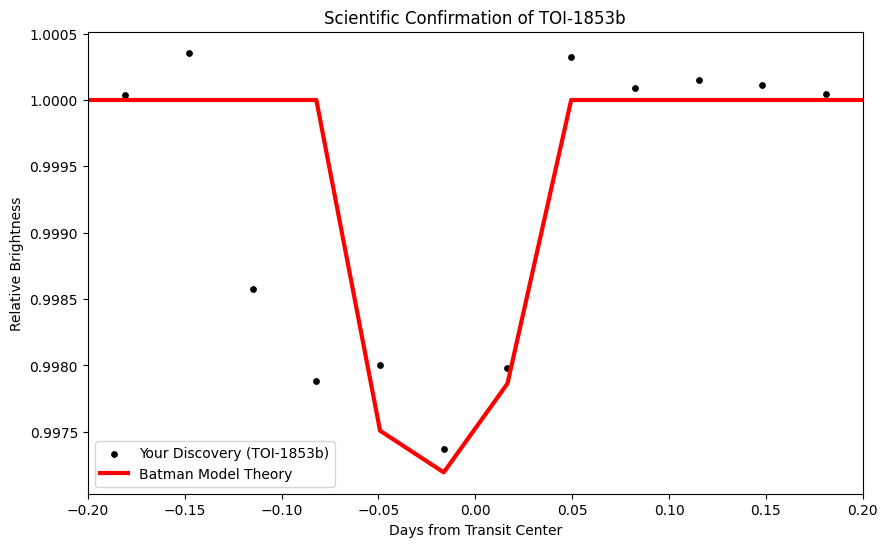

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(binned_lc.time.value, binned_lc.flux.value, color='black', s=15, label='Your Discovery (TOI-1853b)')
plt.plot(t, model_flux, color='red', lw=3, label='Batman Model Theory')

plt.xlabel("Days from Transit Center")
plt.ylabel("Relative Brightness")
plt.title("Scientific Confirmation of TOI-1853b")
plt.legend()
plt.xlim(-0.2, 0.2)
plt.show()